Load dataset

In [112]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
file_path = "../../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)

# Optional: Preview the first few rows
df.head()


,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,CIR_PWR,MAX_NOISE,RXPACC
0,0.0,3.90,745.0,18712.0,10250.0,11855.0,967.0,611.0
1,0.0,0.66,749.0,11239.0,6313.0,18968.0,1133.0,447.0
2,1.0,7.86,746.0,4355.0,5240.0,14699.0,894.0,723.0
3,1.0,3.48,750.0,8502.0,8416.0,8748.0,1127.0,1024.0
4,0.0,1.19,746.0,17845.0,18095.0,11380.0,1744.0,276.0


Check if features are linear

In [113]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np

for col in df.columns:
    X = df[col].values.reshape(-1, 1)
    y = df["NLOS"]

    # Linear Model
    log_reg = LogisticRegression()
    log_reg.fit(X, y)
    y_pred_linear = log_reg.predict_proba(X)[:, 1]

    # Polynomial Model (Degree 2)
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)
    log_reg_poly = LogisticRegression()
    log_reg_poly.fit(X_poly, y)
    y_pred_poly = log_reg_poly.predict_proba(X_poly)[:, 1]

    # Compare AUC Scores
    auc_linear = roc_auc_score(y, y_pred_linear)
    auc_poly = roc_auc_score(y, y_pred_poly)

    print(f"Column: {col}")
    print(f"Linear Model AUC: {auc_linear:.4f}")
    print(f"Polynomial Model AUC: {auc_poly:.4f}\n")

Column: NLOS
Linear Model AUC: 1.0000
Polynomial Model AUC: 1.0000

Column: RANGE
Linear Model AUC: 0.7572
Polynomial Model AUC: 0.7572

Column: FP_IDX
Linear Model AUC: 0.6987
Polynomial Model AUC: 0.6987

Column: FP_AMP1
Linear Model AUC: 0.7611
Polynomial Model AUC: 0.6914

Column: FP_AMP2
Linear Model AUC: 0.7968
Polynomial Model AUC: 0.7406

Column: CIR_PWR
Linear Model AUC: 0.7437
Polynomial Model AUC: 0.7437

Column: MAX_NOISE
Linear Model AUC: 0.6050
Polynomial Model AUC: 0.6050

Column: RXPACC
Linear Model AUC: 0.9047
Polynomial Model AUC: 0.9047



Extract NLOS column and put into y as class labels

In [114]:
X = df.drop(columns=["NLOS"])
y = df["NLOS"]

Split dataset into training and testing with 80:20 ratio


In [126]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (33600, 7)
X_test shape: (8400, 7)


Scale features with StandardScaler

In [116]:
from sklearn.preprocessing import StandardScaler

print("Before Scaling:")
print(X_train.shape)
print(X_train.head())

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("After Scaling:")
print(X_train.shape)
print(X_train[0:5])

Before Scaling:
(33600, 7)
       RANGE  FP_IDX  FP_AMP1  FP_AMP2  CIR_PWR  MAX_NOISE  RXPACC
21278   1.69   747.0   7220.0  10943.0   9179.0     1041.0   292.0
26861   1.81   730.0   2454.0   2914.0   2290.0     1035.0  1024.0
12484   3.99   747.0   4404.0  10013.0  11469.0     1427.0   419.0
38717   0.91   743.0  15608.0  16080.0  12121.0     2645.0   270.0
3917    4.86   744.0   9277.0   9622.0   4065.0     1084.0  1024.0
After Scaling:
(33600, 7)
[[-0.90507112  0.30498732 -0.16907868 -0.07877616 -0.12425514 -0.47485615
  -1.05311879]
 [-0.85421321 -3.53254812 -1.05366913 -1.36503435 -1.52959621 -0.48516967
   1.33175864]
 [ 0.06970548  0.30498732 -0.6917406  -0.2277636   0.3428999   0.18864697
  -0.63934907]
 [-1.23564753 -0.59796219  1.38777082  0.74417916  0.47590648  2.28229153
  -1.12479544]
 [ 0.43842533 -0.37222481  0.21270952 -0.2904024  -1.16750006 -0.40094259
   1.33175864]]


Train model using different C hyperparameter values

Text(0, 0.5, 'Accuracy')

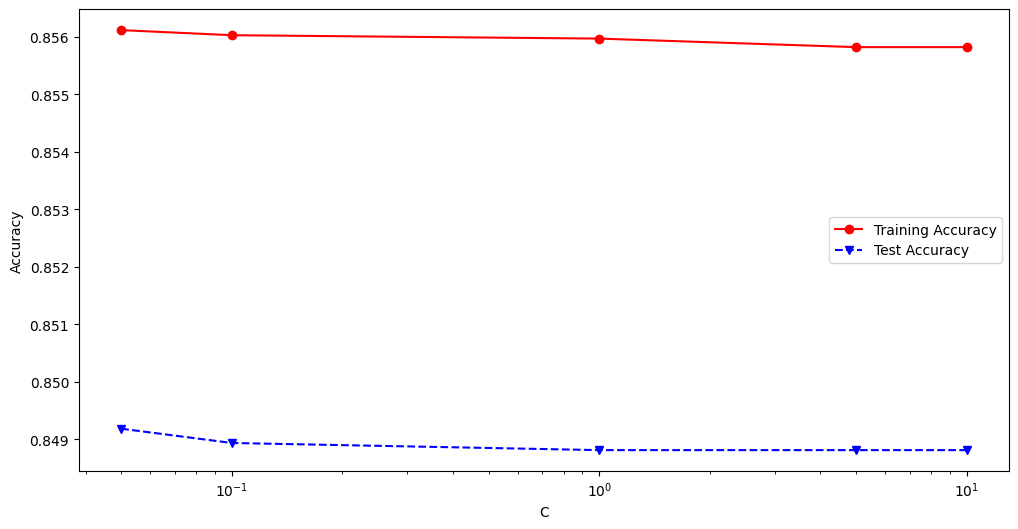

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

C = [0.05, 0.1, 1, 5, 10]

LRTrainAcc = []
LRTestAcc = []

for c in C:
    # Create and train the Logistic Regression model
    logreg = LogisticRegression(C=c, solver='liblinear')
    logreg.fit(X_train, y_train)

    # Predict on the training set
    y_pred_train = logreg.predict(X_train)
    # Predict on the test set
    y_pred_test = logreg.predict(X_test)

    # Evaluate the performance
    train_accuracy_logreg = roc_auc_score(y_train, y_pred_train)
    test_accuracy_logreg = roc_auc_score(y_test, y_pred_test)

    LRTrainAcc.append(train_accuracy_logreg)
    LRTestAcc.append(test_accuracy_logreg)
    

fig, (ax1) = plt.subplots(1, 1, figsize=(12,6))
ax1.plot(C, LRTrainAcc, 'ro-', C, LRTestAcc,'bv--')
ax1.legend(['Training Score','Testing Score'])
ax1.set_xlabel('C')
ax1.set_xscale('log')
ax1.set_ylabel('Score')

AUC-ROC score: 84.88%

Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.90      0.85      4140
         1.0       0.89      0.80      0.84      4260

    accuracy                           0.85      8400
   macro avg       0.85      0.85      0.85      8400
weighted avg       0.85      0.85      0.85      8400

Confusion Matrix:
[[3722  418]
 [ 858 3402]]


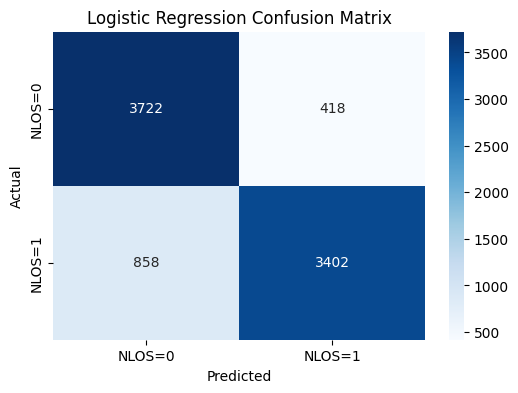

In [ ]:
print("AUC-ROC score: {:.2f}%".format(test_accuracy_logreg * 100))

# Compute and display the confusion matrix
cm_logreg = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:")
print(cm_logreg)

plt.figure(figsize=(6,4))
sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NLOS=0", "NLOS=1"],
            yticklabels=["NLOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Print a classification report which includes precision, recall, f1 score
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))

In [123]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Assuming your training features are in X_train (with the target dropped)
# # If not, create a new DataFrame for feature importance analysis:
# # X_train_no_target = X_train.drop(columns=["NLOS"])
# # Otherwise, if X_train is already defined without "NLOS":
# X_train_no_target = X_train

# # Extract coefficients from the logistic regression model.
# # For binary classification, logreg.coef_ returns a 2D array of shape (1, n_features)
# coefficients = pd.Series(logreg.coef_[0], index=X_train_no_target.columns)

# # Sort coefficients by absolute value (largest magnitude first)
# coefficients_sorted = coefficients.reindex(coefficients.abs().sort_values(ascending=False).index)

# plt.figure(figsize=(8,5))
# ax = sns.barplot(x=coefficients_sorted.values, 
#                  y=coefficients_sorted.index, 
#                  hue=coefficients_sorted.index, 
#                  palette="viridis", 
#                  dodge=False)
# if ax.get_legend() is not None:
#     ax.get_legend().remove()

# plt.xlabel("Coefficient Value")
# plt.ylabel("Feature")
# plt.title("Logistic Regression Coefficients (Feature Importance)")
# plt.show()


In [124]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score
# from sklearn.cluster import DBSCAN
# from sklearn.decomposition import PCA

# # -----------------------------
# # Remove Outliers (Noise) Detected by DBSCAN
# # -----------------------------

# # Add DBSCAN cluster labels to the dataframe
# df["cluster"] = clusters

# # Separate out the noise (-1) from valid data
# df_filtered = df[df["cluster"] != -1].drop(columns=["cluster"])  # Keep only non-noise points

# # Re-define X and y after outlier removal
# X_filtered = df_filtered.drop(columns=["NLOS"])
# y_filtered = df_filtered["NLOS"]

# # Rescale the filtered dataset
# scaler = StandardScaler()
# X_filtered_scaled = scaler.fit_transform(X_filtered)

# # -----------------------------
# # Train Logistic Regression Again After Noise Removal
# # -----------------------------

# # Split dataset after noise removal
# X_train_filtered, X_test_filtered, y_train_filtered, y_test_filtered = train_test_split(
#     X_filtered, y_filtered, test_size=0.3, random_state=111)

# # Train Logistic Regression (After Outlier Removal)
# logreg_after = LogisticRegression(random_state=111, max_iter=500)
# logreg_after.fit(X_train_filtered, y_train_filtered)
# y_pred_after = logreg_after.predict(X_test_filtered)
# accuracy_after = accuracy_score(y_test_filtered, y_pred_after)

# # -----------------------------
# # Compare Accuracy Before and After Outlier Removal
# # -----------------------------
# accuracy_results = pd.DataFrame({
#     "Condition": ["Before Outlier Removal", "After Outlier Removal"],
#     "Accuracy": [round(accuracy_logreg, 4), round(accuracy_after, 4)]
# })

# print("\nAccuracy Comparison:")
# print(accuracy_results)

# # -----------------------------
# # Visualize DBSCAN Clusters Before and After Noise Removal
# # -----------------------------

# # PCA Projection for Visualization
# pca = PCA(n_components=2)
# X_pca_before = pca.fit_transform(X_scaled)  # Before noise removal
# X_pca_after = pca.fit_transform(X_filtered_scaled)  # After noise removal

# # Create DataFrames for visualization
# pca_df_before = pd.DataFrame(X_pca_before, columns=["PCA1", "PCA2"])
# pca_df_before["cluster"] = clusters

# pca_df_after = pd.DataFrame(X_pca_after, columns=["PCA1", "PCA2"])
# pca_df_after["cluster"] = DBSCAN(eps=eps_value, min_samples=min_samples).fit_predict(X_filtered_scaled)

# # Plot Before Noise Removal
# plt.figure(figsize=(8,6))
# sns.scatterplot(data=pca_df_before, x="PCA1", y="PCA2", hue="cluster", palette="viridis", s=60)
# plt.title("DBSCAN Clusters Before Noise Removal")
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.legend(title="Cluster")
# plt.show()

# # Plot After Noise Removal
# plt.figure(figsize=(8,6))
# sns.scatterplot(data=pca_df_after, x="PCA1", y="PCA2", hue="cluster", palette="viridis", s=60)
# plt.title("DBSCAN Clusters After Noise Removal")
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.legend(title="Cluster")
# plt.show()

In [125]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score
# from sklearn.cluster import KMeans
# from sklearn.decomposition import PCA

# # -----------------------------
# # Apply K-Means for Clustering (Instead of DBSCAN)
# # -----------------------------

# kmeans = KMeans(n_clusters=3, random_state=111, n_init=10)  # Adjust the number of clusters as needed
# df["cluster"] = kmeans.fit_predict(X_scaled)  # Assign clusters

# # Find the smallest cluster (assume it contains outliers)
# cluster_counts = df["cluster"].value_counts()
# smallest_cluster = cluster_counts.idxmin()  # Cluster with the fewest data points

# # Remove outliers: Keep only points that are **not** in the smallest cluster
# df_filtered = df[df["cluster"] != smallest_cluster].drop(columns=["cluster"])  # Keep valid points

# # Re-define X and y after outlier removal
# X_filtered = df_filtered.drop(columns=["NLOS"])
# y_filtered = df_filtered["NLOS"]

# # Rescale the filtered dataset
# scaler = StandardScaler()
# X_filtered_scaled = scaler.fit_transform(X_filtered)

# # -----------------------------
# # Train Logistic Regression Again After Noise Removal
# # -----------------------------

# # Split dataset after noise removal
# X_train_filtered, X_test_filtered, y_train_filtered, y_test_filtered = train_test_split(
#     X_filtered, y_filtered, test_size=0.3, random_state=111)

# # Train Logistic Regression (After Outlier Removal with K-Means)
# logreg_after = LogisticRegression(random_state=111, max_iter=500)
# logreg_after.fit(X_train_filtered, y_train_filtered)
# y_pred_after = logreg_after.predict(X_test_filtered)
# accuracy_after = accuracy_score(y_test_filtered, y_pred_after)

# # -----------------------------
# # Compare Accuracy Before and After Outlier Removal
# # -----------------------------
# accuracy_results = pd.DataFrame({
#     "Condition": ["Before Outlier Removal", "After Outlier Removal (K-Means)"],
#     "Accuracy": [round(accuracy_logreg, 4), round(accuracy_after, 4)]
# })

# print("\nAccuracy Comparison with K-Means:")
# print(accuracy_results.to_string(index=False))  # Print without row index

# # -----------------------------
# # Visualize K-Means Clusters Before and After Outlier Removal
# # -----------------------------

# # PCA Projection for Visualization
# pca = PCA(n_components=2)
# X_pca_before = pca.fit_transform(X_scaled)  # Before noise removal
# X_pca_after = pca.fit_transform(X_filtered_scaled)  # After noise removal

# # Create DataFrames for visualization
# pca_df_before = pd.DataFrame(X_pca_before, columns=["PCA1", "PCA2"])
# pca_df_before["cluster"] = kmeans.labels_

# pca_df_after = pd.DataFrame(X_pca_after, columns=["PCA1", "PCA2"])
# pca_df_after["cluster"] = KMeans(n_clusters=3, random_state=111, n_init=10).fit_predict(X_filtered_scaled)

# # Plot Before Outlier Removal
# plt.figure(figsize=(8,6))
# sns.scatterplot(data=pca_df_before, x="PCA1", y="PCA2", hue="cluster", palette="viridis", s=60)
# plt.title("K-Means Clusters Before Noise Removal")
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.legend(title="Cluster")
# plt.show()

# # Plot After Outlier Removal
# plt.figure(figsize=(8,6))
# sns.scatterplot(data=pca_df_after, x="PCA1", y="PCA2", hue="cluster", palette="viridis", s=60)
# plt.title("K-Means Clusters After Noise Removal")
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.legend(title="Cluster")
# plt.show()
